# Compare different effective model potentials

In [1]:
import matplotlib.pyplot as plt

from rydstate import RydbergStateSQDT, RydbergStateSQDTAlkali

## Check Rubidium with large n
For Rubidium and large quantum numbers n we expect the effective model potentials to be very similar.

In [2]:
state = RydbergStateSQDTAlkali("Rb", n=40, l=0, j=0.5)

states: dict[str, RydbergStateSQDTAlkali] = {}


states["marinescu_1994"] = RydbergStateSQDTAlkali.from_angular_ket(
    state.species, state.angular, n=state.n, potential="marinescu_1994"
)

states["fei_2009"] = RydbergStateSQDTAlkali.from_angular_ket(
    state.species, state.angular, n=state.n, potential="fei_2009"
)

for label, state in states.items():
    print(f"Integrating wavefunction for {label}")
    state.radial.integrate_wavefunction()

Integrating wavefunction for marinescu_1994
Integrating wavefunction for fei_2009


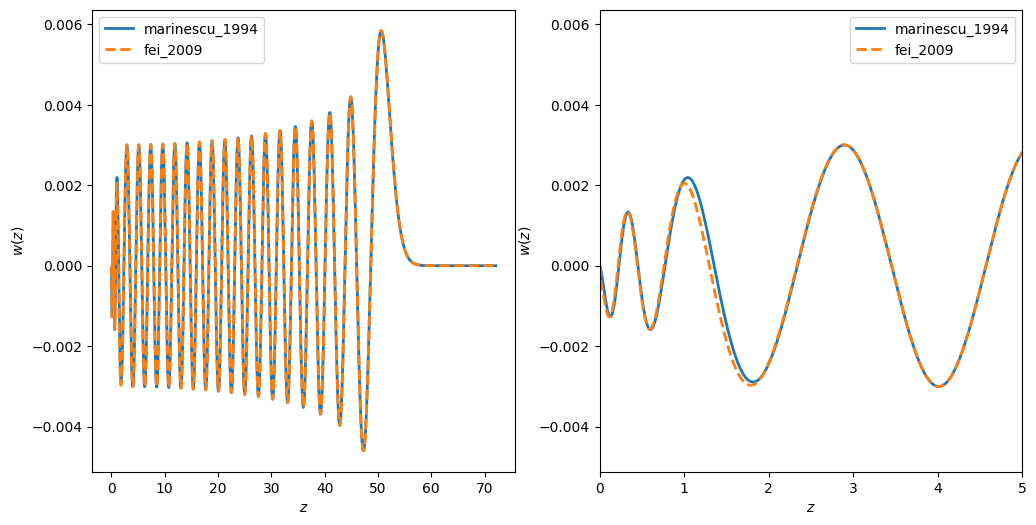

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for ax in axs:
    linestyles = ["-", "--", "-.", ":"]
    for label, state in states.items():
        ax.plot(state.radial.z_list, state.radial.w_list, label=label, lw=2, ls=linestyles.pop(0))

    ax.legend()
    ax.set_xlabel("$z$")
    ax.set_ylabel("$w(z)$")

axs[1].set_xlim(0, 5)

plt.show()

## Big differences for Strontium with small n

In [4]:
state = RydbergStateSQDT("Sr88", n=8, l_r=0, j_tot=0, s_tot=0)

states: dict[str, RydbergStateSQDT] = {}


states["marinescu_1994"] = RydbergStateSQDT.from_angular_ket(
    state.species, state.angular, n=state.n, potential="marinescu_1994"
)

states["fei_2009"] = RydbergStateSQDT.from_angular_ket(state.species, state.angular, n=state.n, potential="fei_2009")

for label, state in states.items():
    print(f"Integrating wavefunction for {label}")
    state.radial.integrate_wavefunction()

The wavefunction for the radial_ket RadialKet(nu=4.742213450510572, potential=PotentialMarinescu1994Strontium88(l_r=0)) has some issues:
      The wavefunction is not close to zero at the inner boundary (inner_weight_scaled_to_whole_grid=5.99e-01)
      The wavefunction has 3 nodes, but should have 7 nodes.
      The integration for l=0 did stop at 1.69 (should be close to zero).


Integrating wavefunction for marinescu_1994
Integrating wavefunction for fei_2009


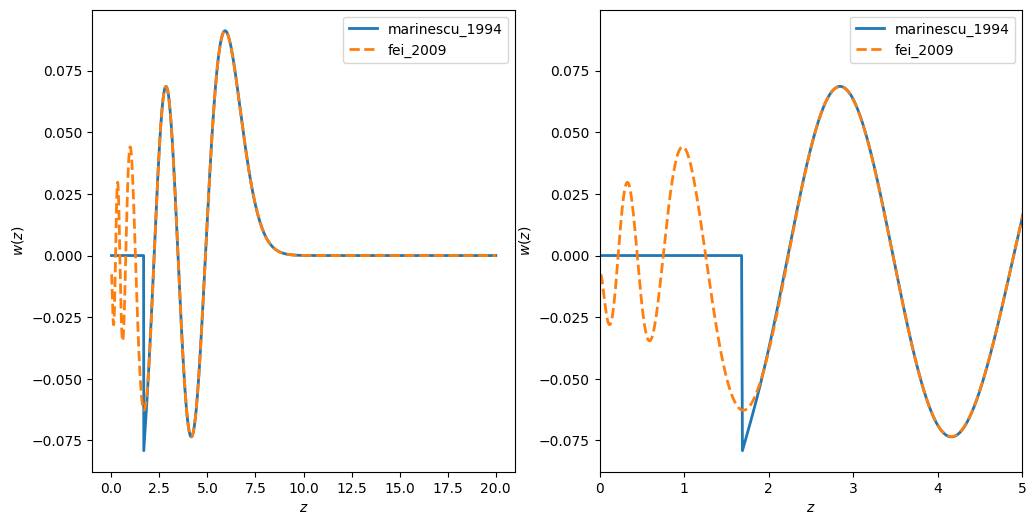

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

for ax in axs:
    linestyles = ["-", "--", "-.", ":"]
    for label, state in states.items():
        ax.plot(state.radial.z_list, state.radial.w_list, label=label, lw=2, ls=linestyles.pop(0))

    ax.legend()
    ax.set_xlabel("$z$")
    ax.set_ylabel("$w(z)$")

axs[1].set_xlim(0, 5)

plt.show()